In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# ERCO
#select path ERCO.xlsx in DATAISOS
path = "DATAISOS/MISO.xlsx"
df = pd.read_excel(path, sheet_name="Published Hourly Data")

In [5]:
#define span period
start_date = "2019-01-01"
end_date = "2025-12-31"
#convert date column to datetime

#filter data by span period
df = df[(df["UTC time"] >= start_date) & (df["UTC time"] <= end_date)]
df

,BA,UTC time,Local date,Hour,Local time,Time zone,Generation only?,Demand forecast,Demand,Net generation,...,CO2 Emissions: OIL,CO2 Emissions: Other,CO2 Emissions Generated,CO2 Emissions Imported,CO2 Emissions Exported,CO2 Emissions Consumed,Positive Generation,Consumed Electricity,CO2 Emissions Intensity for Generated Electricity,CO2 Emissions Intensity for Consumed Electricity
30714,MISO,2019-01-01 00:00:00,2018-12-31,19,2018-12-31 19:00:00,Eastern Standard,N,81595.0,74304.0,70466.0,...,NaN,187.371193,36324.660540,2544.985616,684.052813,38185.593343,70466.0,76142.0,1.136464,1.105628
30715,MISO,2019-01-01 01:00:00,2018-12-31,20,2018-12-31 20:00:00,Eastern Standard,N,80484.0,73391.0,69693.0,...,NaN,189.424740,35396.944023,2411.521467,721.294404,37087.171085,69693.0,75121.0,1.119722,1.088419
30716,MISO,2019-01-01 02:00:00,2018-12-31,21,2018-12-31 21:00:00,Eastern Standard,N,78470.0,71531.0,67805.0,...,NaN,186.886051,34097.521123,2325.426105,755.006254,35667.940974,67805.0,73036.0,1.108651,1.076651
30717,MISO,2019-01-01 03:00:00,2018-12-31,22,2018-12-31 22:00:00,Eastern Standard,N,76301.0,69562.0,66177.0,...,NaN,186.567054,32739.873485,2039.804489,633.771983,34145.905990,66178.0,71118.0,1.090679,1.058505
30718,MISO,2019-01-01 04:00:00,2018-12-31,23,2018-12-31 23:00:00,Eastern Standard,N,73623.0,67744.0,64142.0,...,NaN,185.716394,30968.154305,2033.740507,577.911637,32423.983174,64143.0,69178.0,1.064388,1.033314
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92054,MISO,2025-12-30 20:00:00,2025-12-30,15,2025-12-30 15:00:00,Eastern Standard,N,83578.0,82109.0,85386.0,...,NaN,133.114923,37386.708887,1306.766799,1797.105429,36896.370257,85632.0,84444.0,0.962531,0.963271
92055,MISO,2025-12-30 21:00:00,2025-12-30,16,2025-12-30 16:00:00,Eastern Standard,N,82949.0,81141.0,84342.0,...,NaN,136.890370,35905.560345,1432.478421,1739.397260,35598.641505,84517.0,83563.0,0.936594,0.939189
92056,MISO,2025-12-30 22:00:00,2025-12-30,17,2025-12-30 17:00:00,Eastern Standard,N,83580.0,81074.0,84875.0,...,NaN,133.670584,36585.652157,1428.280252,1846.467730,36167.464679,84876.0,83501.0,0.950298,0.954905
92057,MISO,2025-12-30 23:00:00,2025-12-30,18,2025-12-30 18:00:00,Eastern Standard,N,86199.0,82958.0,86971.0,...,NaN,130.138715,38453.096179,1194.153933,1550.766565,38096.483547,86970.0,85687.0,0.974755,0.980175


In [6]:
rename_map = {
            'Local date':                                        'Date',
            'Demand':                                            'D',
            'Net generation':                                    'NG',
            'CO2 Emissions Generated':                           'daily_emissions',
            'NG: COL':                                           'Gen_Coal',
            'NG: NG':                                            'Gen_Gas',
            'NG: NUC':                                           'Gen_Nuclear',
            'NG: WND':                                           'Gen_Wind',   
            'NG: SUN':                                           'Gen_Sun',
            'NG: OTH':                                           'Gen_Others',
            'NG: OIL':                                           'Gen_Oil'
        }
#rename columns
df.rename(columns=rename_map, inplace=True)

In [7]:
#keep only the columns we need
cols= [
            'Date','D', 'NG', 'daily_emissions', 'Gen_Coal', 'Gen_Gas', 'Gen_Nuclear',
            'Gen_Wind', 'Gen_Sun', 'Gen_Others', 'Gen_Oil'
        ]
df = df[cols]
df

,Date,D,NG,daily_emissions,Gen_Coal,Gen_Gas,Gen_Nuclear,Gen_Wind,Gen_Sun,Gen_Others,Gen_Oil
30714,2018-12-31,74304.0,70466.0,36324.660540,30814.0,11458.0,11970.0,13981.0,0.0,1012.0,NaN
30715,2018-12-31,73391.0,69693.0,35396.944023,30051.0,11139.0,11987.0,14254.0,0.0,1015.0,NaN
30716,2018-12-31,71531.0,67805.0,34097.521123,28954.0,10730.0,11995.0,13915.0,0.0,1038.0,NaN
30717,2018-12-31,69562.0,66177.0,32739.873485,27801.0,10304.0,12001.0,13946.0,0.0,1021.0,NaN
30718,2018-12-31,67744.0,64142.0,30968.154305,26168.0,10030.0,12006.0,13858.0,0.0,1012.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
92054,2025-12-30,82109.0,85386.0,37386.708887,25654.0,25002.0,12012.0,13612.0,8436.0,319.0,NaN
92055,2025-12-30,81141.0,84342.0,35905.560345,24620.0,23929.0,12010.0,15902.0,7133.0,309.0,NaN
92056,2025-12-30,81074.0,84875.0,36585.652157,24837.0,24917.0,12017.0,17332.0,4608.0,306.0,NaN
92057,2025-12-30,82958.0,86971.0,38453.096179,25815.0,26961.0,12011.0,18871.0,1190.0,308.0,NaN


Text(0.5, 1.0, 'Missing Values Heatmap')

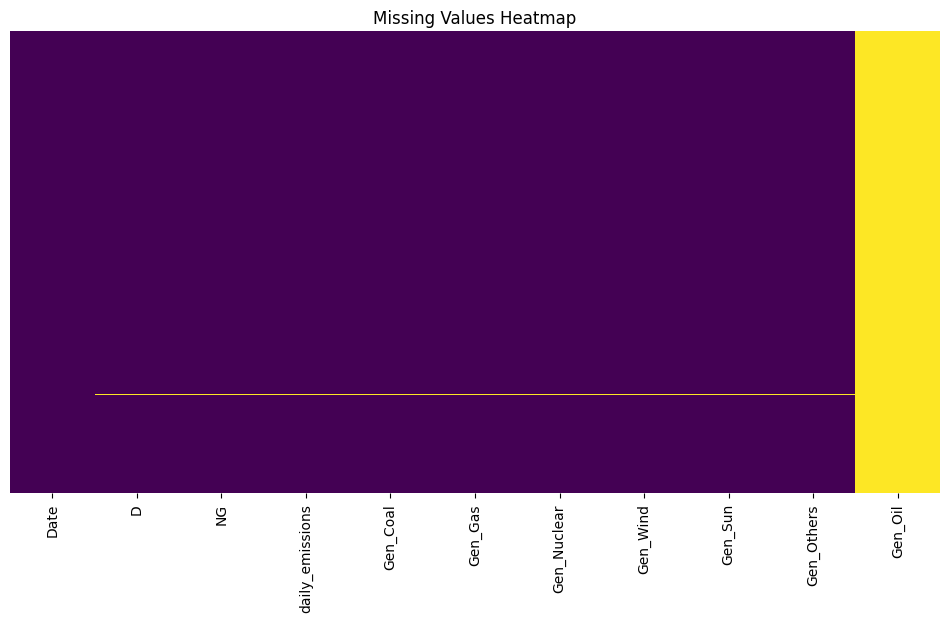

In [8]:
#plot missing values per column per row

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')



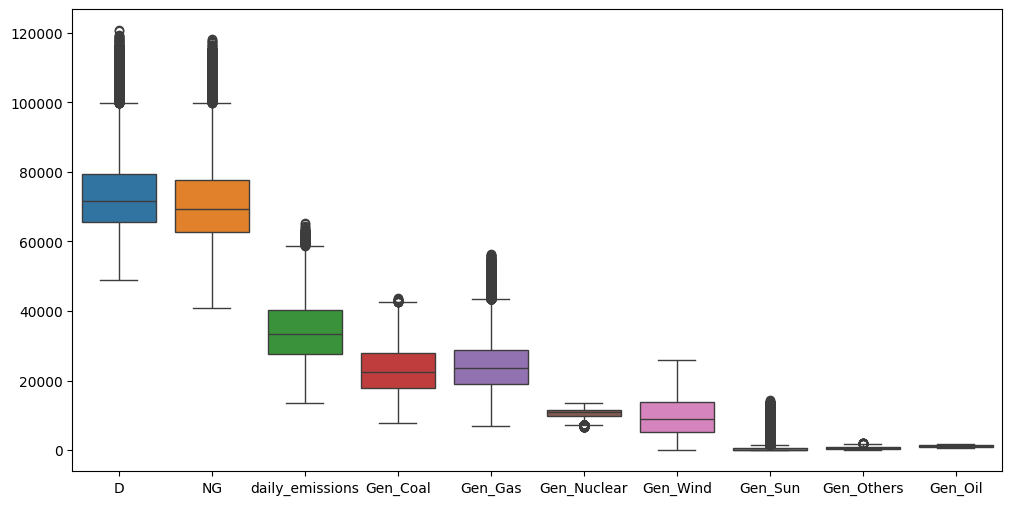

In [9]:
#plot boxplot of all columns
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
#set outliers to Nan
for col in df.columns:
    #not for date column
    if col == "Date":
        continue
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].apply(lambda x: x if lower_bound <= x <= upper_bound else pd.NA)
       

<Axes: >

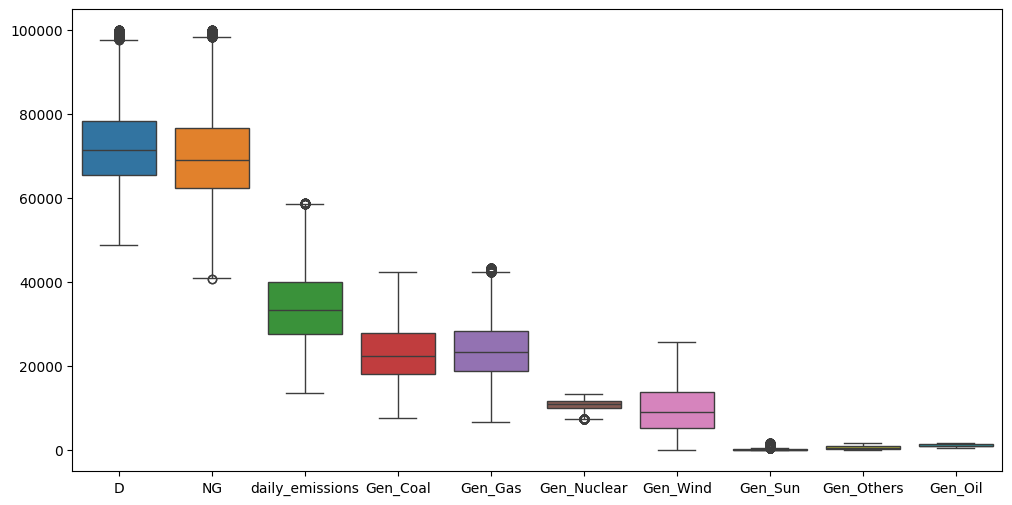

In [10]:
#plot the boxplot again after removing outliers
plt.figure(figsize=(12, 6)) 
sns.boxplot(data=df)

Text(0.5, 1.0, 'Missing Values Heatmap')

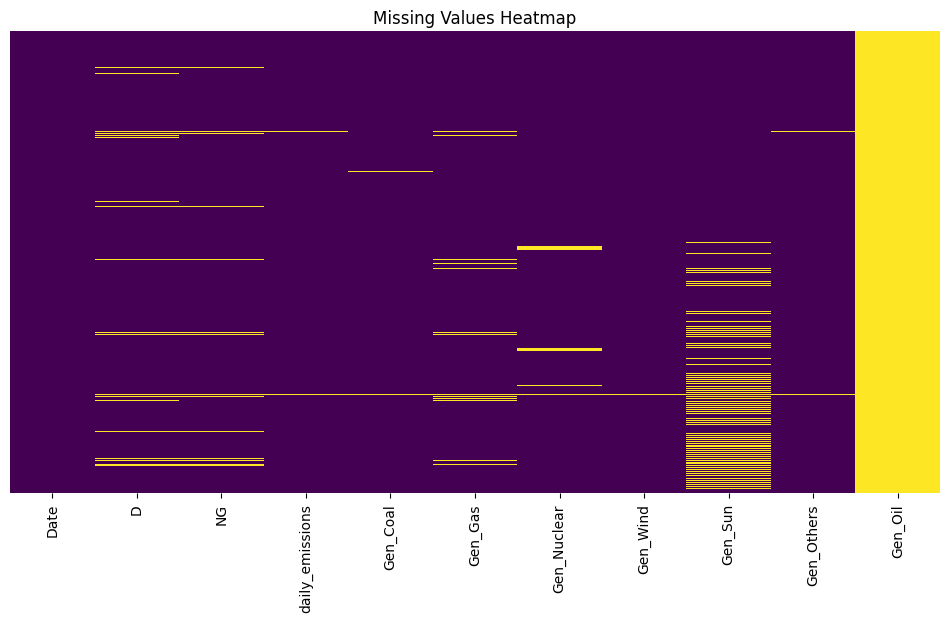

In [11]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')



In [12]:

# do interpolation for all columns except date
for col in df.columns:
    if col == "Date":
        continue
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = pd.Series(df[col]).interpolate(method='cubic', limit_direction='both')

<Axes: xlabel='Date', ylabel='daily_emissions'>

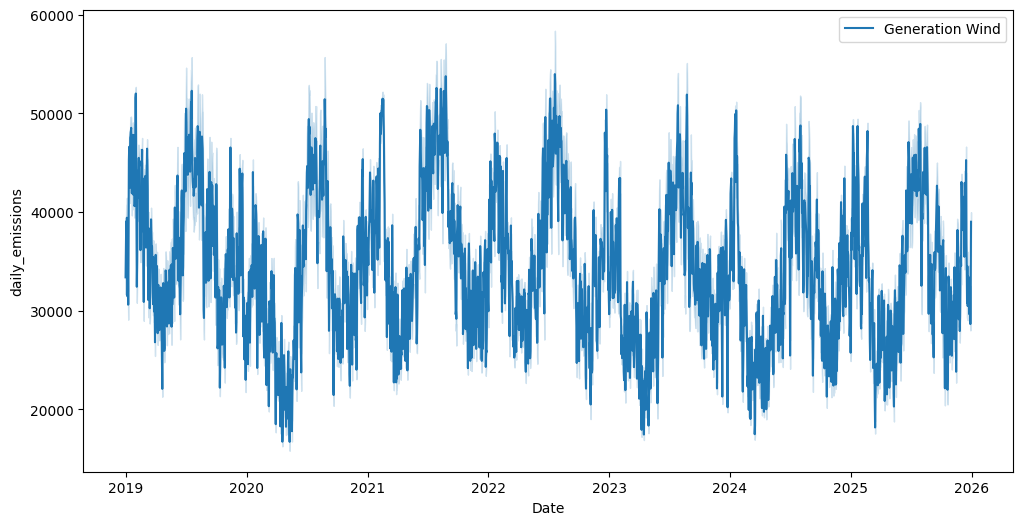

In [13]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Date", y="daily_emissions", label="Generation Wind")